In [10]:
import pandas as pd
import os
import re

# ------------------ 配置 ------------------
data_folder = "./data"
last_three = ["年龄", "性别", "民族"]

# 获取所有 Excel 文件
excel_files = [f for f in os.listdir(data_folder) if f.endswith(".xlsx")]

# 用于存储处理后的 DataFrame
dfs = []

# ------------------ 批量处理 ------------------
for file in excel_files:
    file_path = os.path.join(data_folder, file)
    df_raw = pd.read_excel(file_path, engine="openpyxl")

    # ------------------ 1. 保留基础列 ------------------
    base_cols = ["用户ID", "作答总时长(秒)", "省份", "城市"]
    start_col = df_raw.columns[17]
    cols_to_keep = base_cols + list(df_raw.columns[df_raw.columns.get_loc(start_col):])
    df = df_raw[cols_to_keep]

    # ------------------ 2. 处理家庭结构可能性列 ------------------
    probability = "以下这种关系属于家庭结构的可能性有多大"
    probability_columns = {}
    for col in df.columns:
        if probability in col:
            if "-" in col:
                after_dash = col.split("-", 1)[1]
            else:
                after_dash = col.replace(probability, "").strip()
            probability_col_name = after_dash + "_可能性"
            probability_columns[col] = probability_col_name
    df = df.rename(columns=probability_columns)

    # ------------------ 3. 重命名关系评价列 ------------------
    question = r'请您根据对“(.+?)”关系的理解，在以下一系列维度上进行评价-(.+)'
    question_columns = {}
    for col in df.columns:
        m = re.match(question, col)
        if m:
            relation = m.group(1)
            dimension = m.group(2)
            new_name = f"{relation}_{dimension}"
            question_columns[col] = new_name
    df = df.rename(columns=question_columns)

    # ------------------ 4. 删除不需要的列 ------------------
    cols_to_drop = [
        '请问您刚才的选择，“夫妻属于家庭结构的可能性”，是否大于50%？',
        '最高教育程度为',
        '感谢您参加本次调查。您的回答对我们很重要。如有建议与疑问，恳请提供。'
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # 删除第一行
    df = df.drop(index=0).reset_index(drop=True)

    # ------------------ 5. 民族列改名 ------------------
    if "请填写您的民族" in df.columns:
        df = df.rename(columns={"请填写您的民族": "民族"})

    # ------------------ 6. 提前最后三列到用户ID后面 ------------------
    uid_index = df.columns.get_loc("用户ID")
    other_cols = [c for c in df.columns if c not in last_three and c != "用户ID"]
    new_col_order = list(df.columns[:uid_index+1]) + last_three + other_cols
    df = df[new_col_order]

    # ------------------ 7. 宽表 -> 长表 ------------------
    underscore_cols = [c for c in df.columns if "_" in c]

    df_long = df.melt(
        id_vars=["用户ID"] + last_three,
        value_vars=underscore_cols,
        var_name="temp",
        value_name="值"
    )

    df_long["关系"] = df_long["temp"].apply(lambda x: x.split("_", 1)[0])
    df_long["指标"] = df_long["temp"].apply(lambda x: x.split("_", 1)[1])
    df_long = df_long.drop(columns=["temp"])

    df_long = df_long[["用户ID", "年龄", "性别", "民族", "关系", "指标", "值"]]

    # ------------------ 8. 保存到列表 ------------------
    dfs.append(df_long)
    df_long['指标'] = df_long['指标'].replace('服务交换.1', '服务交换')

# ------------------ 9. 合并所有数据 ------------------
df_all = pd.concat(dfs, ignore_index=True)

df_all.to_excel("./merged_long.xlsx", index=False, engine="openpyxl")

print(df_all.shape)
print(df_all)

(24125, 7)
           用户ID  年龄 性别  民族           关系    指标    值
0      M28Jk0AL  40  女   汉           夫妻   可能性   70
1      LQ82jnv7  20  女  汉族           夫妻   可能性  100
2      J7qqJky7  20  男   汉           夫妻   可能性  100
3      Mr5BlD5e  21  男   汉           夫妻   可能性  100
4      veEb1B6M  20  女  汉族           夫妻   可能性  100
...         ...  .. ..  ..          ...   ...  ...
24120  MWWmQlGM  21  女   汉  同母异父兄-同母异父妹  代沟评估   16
24121  4enyXAWL  20  女   汉  同母异父兄-同母异父妹  代沟评估  NaN
24122  M9X4BP9e  20  女   汉  同母异父兄-同母异父妹  代沟评估  NaN
24123  7Yp1XnzM  20  女  汉族  同母异父兄-同母异父妹  代沟评估    3
24124  Mo1ZPaOL  30  女   汉  同母异父兄-同母异父妹  代沟评估  NaN

[24125 rows x 7 columns]


In [11]:
df_all["值"] = pd.to_numeric(df_all["值"], errors="coerce")
df_all_clean = df_all[df_all['值'].notna() & (df_all['值'] != '')]

df_all_clean = df_all_clean[df_all_clean["指标"] != "可能性"]


print(df_all_clean.shape)
print(df_all_clean)


(11512, 7)
           用户ID  年龄 性别  民族           关系    指标     值
5      M28Jk0AL  40  女   汉           夫妻  关系效价  63.0
6      LQ82jnv7  20  女  汉族           夫妻  关系效价  90.0
7      J7qqJky7  20  男   汉           夫妻  关系效价  80.0
8      Mr5BlD5e  21  男   汉           夫妻  关系效价  80.0
9      veEb1B6M  20  女  汉族           夫妻  关系效价  80.0
...         ...  .. ..  ..          ...   ...   ...
24113  7Yp1XnzM  20  女  汉族  同母异父兄-同母异父妹  品德评估  74.0
24115  MWWmQlGM  21  女   汉  同母异父兄-同母异父妹  信任评估  59.0
24118  7Yp1XnzM  20  女  汉族  同母异父兄-同母异父妹  信任评估  66.0
24120  MWWmQlGM  21  女   汉  同母异父兄-同母异父妹  代沟评估  16.0
24123  7Yp1XnzM  20  女  汉族  同母异父兄-同母异父妹  代沟评估   3.0

[11512 rows x 7 columns]


In [5]:
# !pip install matplotlib
# !pip install seaborn
# !pip install scikit-learn

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
import seaborn as sns
from sklearn import manifold, preprocessing

关系         三从兄-三从弟      义母-义女  义母-义子  义父-义女  义父-义子  亲家-亲家  从祖姑-从侄孙  从祖母-从孙女  \
指标                                                                            
互动强度          71.0  76.000000  70.75   31.0   50.0   69.0     67.5     39.0   
交配            10.0  10.000000  14.00   65.0    0.0    0.0     40.0    100.0   
亲密性           57.0  49.000000  46.00   47.0   68.0   52.5     66.5     53.0   
代沟评估           8.0  75.000000  75.75   61.0   64.0   13.5     76.0    100.0   
依恋            11.0  77.333333  53.00   36.0   69.0   52.5     50.0     35.0   
信任评估          23.0  66.000000  66.75   37.0   29.0   66.0     71.5     68.0   
信息传递          14.0  81.666667  64.75   61.0   80.0   75.0     57.5     17.0   
共有式分享         69.0  55.333333  59.50   40.0   71.0   66.0     63.5     81.0   
关系效价          75.0  83.666667  76.00   77.0   61.0   79.0     71.0     83.0   
具体性           67.0  38.333333  40.00   77.0   24.0   45.0     20.5      7.0   
冲突            59.0  13.666667  23.75   50.0   59.0  

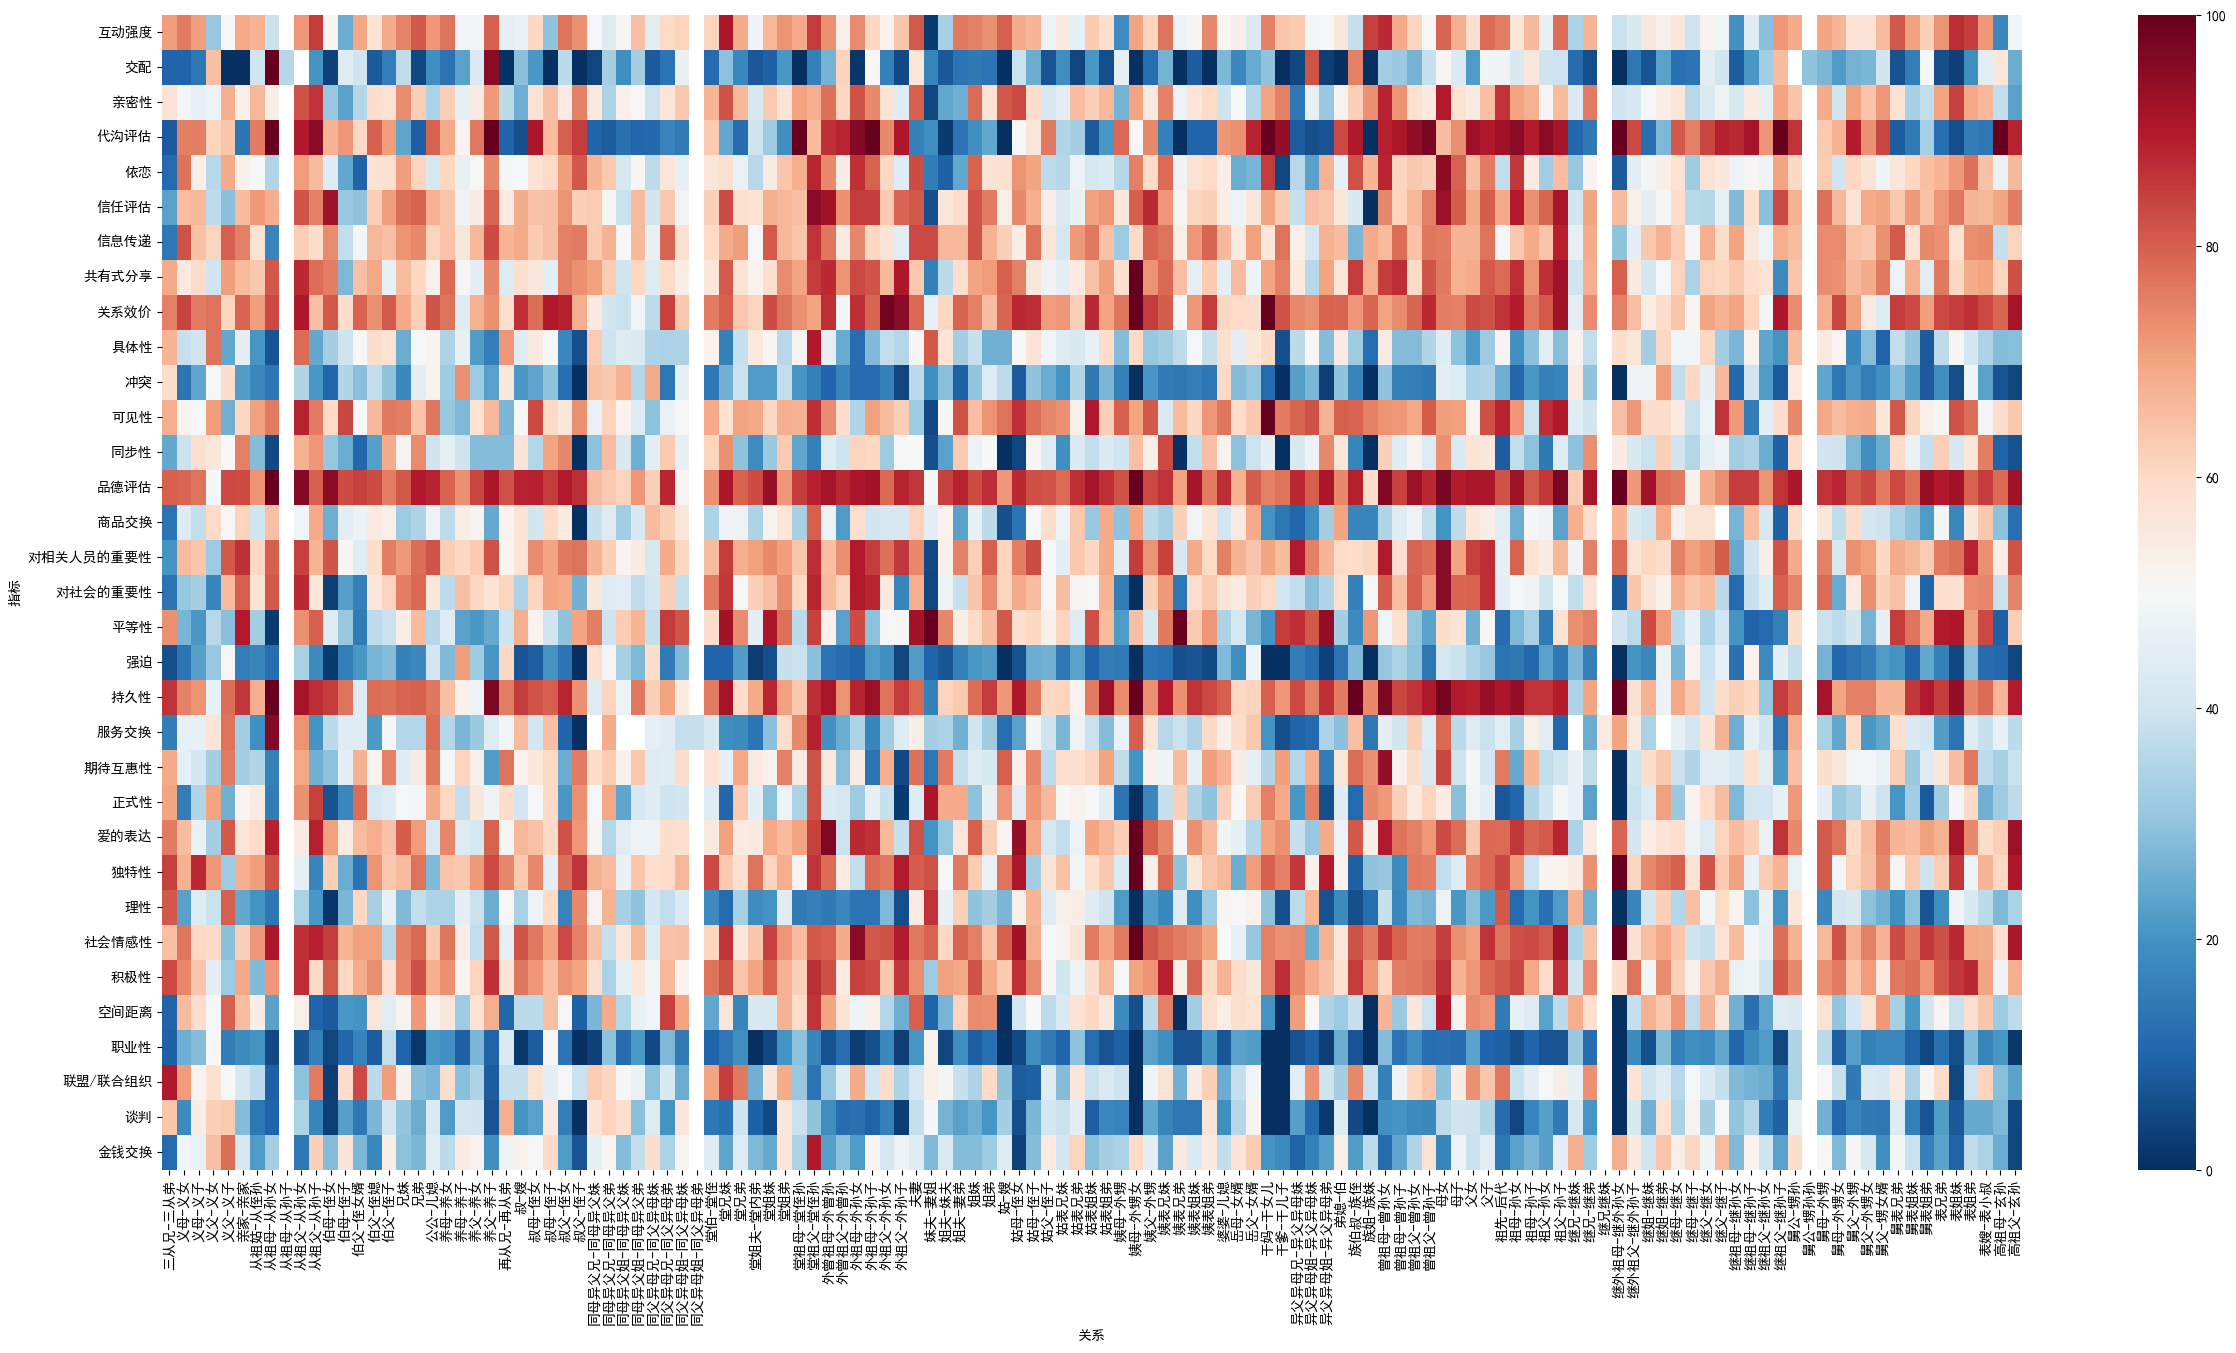

In [12]:
df_mean = df_all_clean.groupby(["关系", "指标"])["值"].mean().unstack()
df_restructured = df_mean.transpose()

plt.figure(figsize=(30,15))
sns.heatmap(df_restructured, center=50,cmap="RdBu_r")

dim_rel_scaled = preprocessing.scale(df_restructured.transpose())
dim_rel_scaled = pd.DataFrame(dim_rel_scaled,index=df_restructured.columns,columns=df_restructured.index)


value = df_restructured.iloc[0, 0]
print(df_restructured)
print(value)